In [3]:
#Import necessary Libraries

import os
import warnings
import tensorflow as tf
import seaborn as sns
import random
import numpy as np
from tensorflow.keras.callbacks import Callback
from keras import models, layers
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint

# Ignore warnings

warnings.filterwarnings("ignore")

# Set Seed

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Define Dataset Paths

# train_path = '/kaggle/input/brain-tumor-mri-dataset/Training'
# test_path = '/kaggle/input/brain-tumor-mri-dataset/Testing'
train_path = 'D:\AHMED ALAA\GTC\Final Project\Training'
test_path = 'D:\AHMED ALAA\GTC\Final Project\Testing'

In [4]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(299,299),
    batch_size=32,
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(299,299),
    batch_size=32,
    shuffle=True,
    seed=SEED
)

Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.


In [5]:
# Augment Dataset

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

data_augmentation_2 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
augmented_train_ds_2 = train_ds.map(lambda x, y: (data_augmentation_2(x, training=True), y))

In [6]:
train_ds = train_ds.concatenate(augmented_train_ds)
train_ds = train_ds.concatenate(augmented_train_ds_2)

# Data PreProcessing

In [7]:
def dataset_to_numpy(dataset):
    x, y = [], []
    for images, labels in dataset:
        images = tf.image.rgb_to_grayscale(images)
        images = tf.cast(images, tf.float32) / 255.0
        x.append(images.numpy())
        y.append(labels.numpy())
    return np.concatenate(x), np.concatenate(y)

x_train, y_train = dataset_to_numpy(train_ds)
x_test, y_test   = dataset_to_numpy(test_ds)

y_train = to_categorical(y_train, num_classes=4)
y_test  = to_categorical(y_test, num_classes=4)


x_train_new, x_val, y_train_new, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=SEED)

In [8]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# EDA

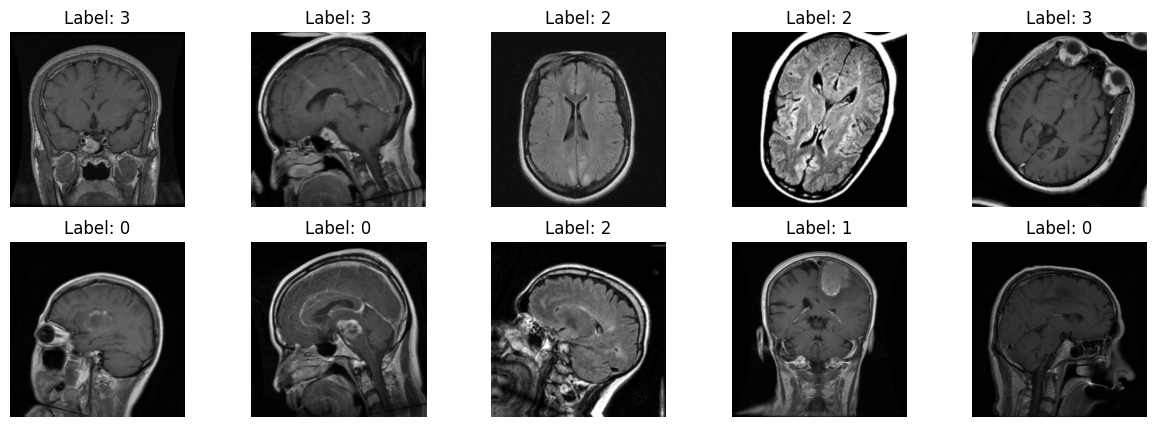

In [ ]:
num_images = 10
images = x_train_new[:num_images]
labels = y_train_new[:num_images]

plt.figure(figsize=(15, 5))
for i in range(num_images):
    plt.subplot(2, 5, i+1)

    img = images[i]
    plt.imshow(img.squeeze(), cmap="gray")
    
    label = labels[i].argmax() if labels.ndim > 1 else labels[i]
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.show()

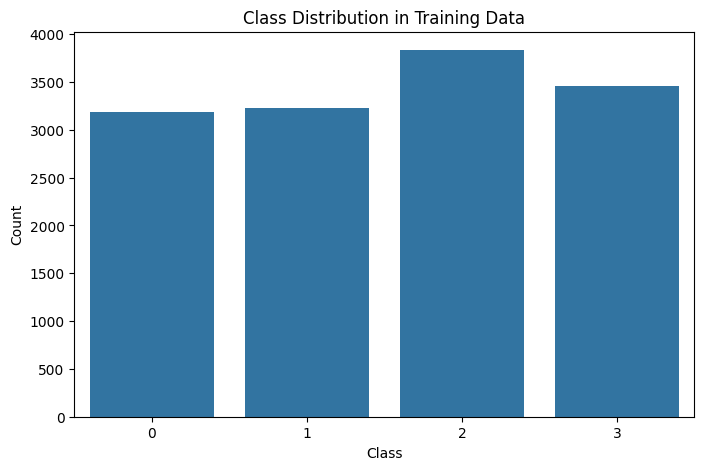

In [15]:
if y_train_new.ndim > 1:
    y_labels = np.argmax(y_train_new, axis=1)
else:
    y_labels = y_train_new

plt.figure(figsize=(8,5))
sns.countplot(x=y_labels)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution in Training Data")
plt.show()

*Data is almost balanced*

# Training

In [ ]:
from model import create_model, DualMetricCheckpoint


checkpoint = DualMetricCheckpoint("best_model.h5")

input_shape = x_train_new.shape[1:]
model = create_model(input_shape)

history = model.fit(
    x_train_new, y_train_new,
    epochs=15,
    batch_size=32,
    verbose=1,
    validation_data=(x_val, y_val),
    callbacks=[checkpoint]
)

Epoch 1/15
  4/429 ━━━━━━━━━━━━━━━━━━━━ 17:26 2s/step - accuracy: 0.2565 - loss: 1.5657

KeyboardInterrupt: 

# Evaluation

In [10]:
model.load_weights("best_model.h5")

train_loss_best, train_acc_best = model.evaluate(x_train, y_train, verbose=0)
val_loss_best, val_acc_best = model.evaluate(x_val, y_val, verbose=0)
test_loss_best, test_acc_best = model.evaluate(x_test, y_test, verbose=0)

model.save("/kaggle/working/OncoVision.h5")

print("\n=== Best Model Evaluation ===\n")
print(f"Train Accuracy:       {train_acc_best:.4f}   | Training loss:    {train_loss_best:.4}")
print(f"Validation Accuracy:  {val_acc_best:.4f}   | Validation loss:  {val_loss_best:.4}")
print(f"Test Accuracy:        {test_acc_best:.4f}   | Test loss:        {test_loss_best:.4}")

2025-09-16 22:59:53.980511: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-09-16 23:00:11.278662: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


=== Best Model Evaluation ===

Train Accuracy:       0.9942   | Training loss:    0.4253
Validation Accuracy:  0.9825   | Validation loss:  0.4487
Test Accuracy:        0.9863   | Test loss:        0.4377


In [ ]:
y_true = np.argmax(y_test, axis=1)

y_pred = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred, axis=1)

report = classification_report(y_true, y_pred, target_names=class_names)
print("\n\n=== Classification Report ===\n\n")
print(report)

2025-09-16 23:00:16.990297: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}




=== Classification Report ===


              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       300
  meningioma       0.98      0.96      0.97       306
     notumor       0.99      1.00      0.99       405
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



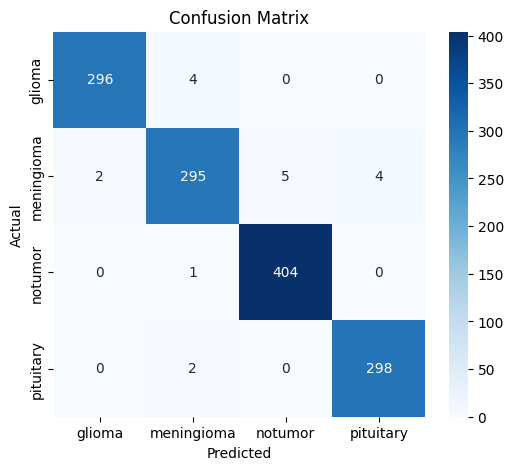

In [12]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Visualization

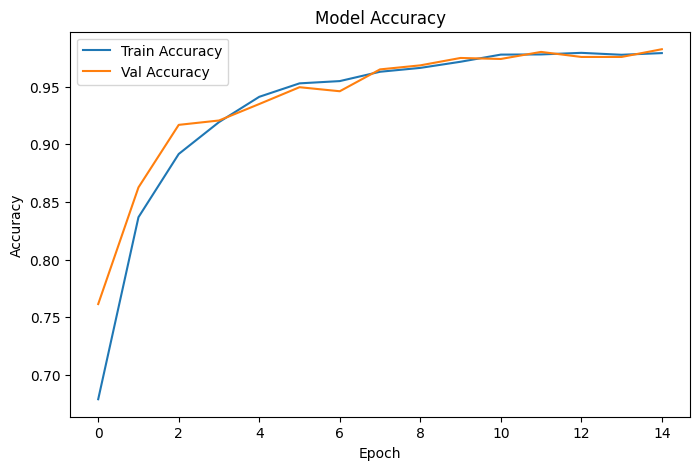

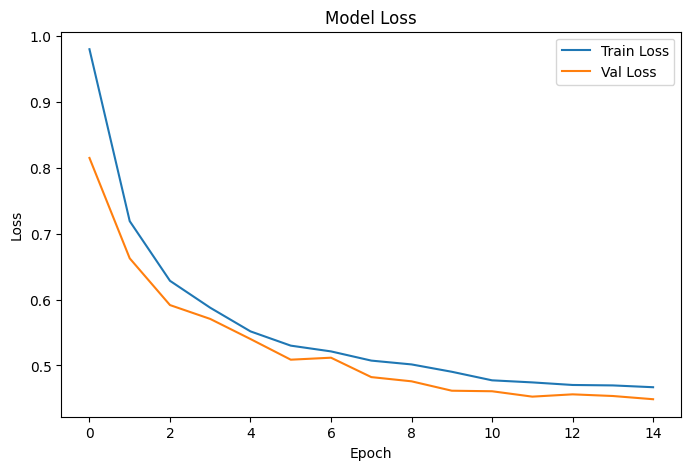

In [13]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()